**فصل دوم: ماشین‌لرنینگ روی صدا — درس ۷**


# 🧩 ساخت ماشین دروغ‌سنج (تشخیص احساسات) صوتی

### 1️⃣ نصب و فراخوانی کتابخانه‌ها

In [3]:
%pip install -v -i https://mirror-pypi.runflare.com/simple numpy pandas matplotlib seaborn scikit-learn sounddevice soundfile librosa joblib --trusted-host mirror-pypi.runflare.com

Using pip 26.1.1 from c:\Users\mosta\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip (python 3.12)
Looking in indexes: https://mirror-pypi.runflare.com/simple
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import sounddevice as sd
import soundfile as sf
import librosa
import joblib

### 2️⃣ بارگذاری گنجینه داده‌ها 


In [5]:
# X_train, X_test, y_train, y_test 
data = np.load('emotion_data.npz', allow_pickle=True)
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

print(f"داده‌ها بارگذاری شدند")
print(f"X_train shape:\n {X_train.shape},\n X_test shape:\n {X_test.shape}")
print(f"کلاس‌های احساس:\n {np.unique(y_train)}")

داده‌ها بارگذاری شدند
X_train shape:
 (1152, 15),
 X_test shape:
 (288, 15)
کلاس‌های احساس:
 ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


### 3️⃣   تعریف و آموزش دو مدل منتخب



In [6]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("آموزش داده شد Random Forest")
 
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)
print("آموزش داده شد SVM")

آموزش داده شد Random Forest
آموزش داده شد SVM


### 4️⃣  ارزیابی و مقایسه دقت مدل‌ها


In [11]:
# پیش‌بینی روی تست
y_pred_rf = rf_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)

# دقت
acc_rf = accuracy_score(y_test, y_pred_rf)
acc_svm = accuracy_score(y_test, y_pred_svm)

print(f"🎯 Random Forest : {acc_rf:.2%}")
print(f"🎯 SVM           : {acc_svm:.2%}")

# انتخاب مدل برتر
if acc_rf >= acc_svm:
    best_model = rf_model
    best_name = "Random Forest"
else:
    best_model = svm_model
    best_name = "SVM"

print(f"\nمدل برتر برای ادامه:\n{best_name}")

🎯 Random Forest : 55.56%
🎯 SVM           : 50.35%

مدل برتر برای ادامه:
Random Forest


### 5️⃣ نمایش ماتریس درهم‌ریختگی برای مدل برتر


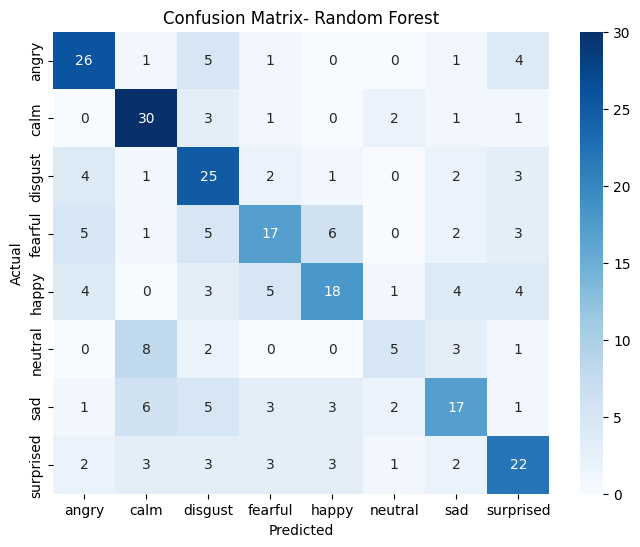


 گزارش دسته‌بندی برای مدل برتر:
              precision    recall  f1-score   support

       angry       0.62      0.68      0.65        38
        calm       0.60      0.79      0.68        38
     disgust       0.49      0.66      0.56        38
     fearful       0.53      0.44      0.48        39
       happy       0.58      0.46      0.51        39
     neutral       0.45      0.26      0.33        19
         sad       0.53      0.45      0.49        38
   surprised       0.56      0.56      0.56        39

    accuracy                           0.56       288
   macro avg       0.55      0.54      0.53       288
weighted avg       0.55      0.56      0.55       288



In [ ]:
# محاسبه ماتریس
cm = confusion_matrix(y_test, best_model.predict(X_test))
classes = np.unique(y_test)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title(f'Confusion Matrix- {best_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\n گزارش دسته‌بندی برای مدل برتر:")
print(classification_report(y_test, best_model.predict(X_test)))

### 6️⃣  آماده‌سازی برای تست زنده


In [9]:
# توجه: قبل از ران کردن این سلول باید طبق آموزش داخل ویدیو، اسکیلر را ذخیره کنید

scaler_path = 'scaler.pkl'

scaler = joblib.load(scaler_path)
print(" بارگذاری شد StandardScaler ")

 بارگذاری شد StandardScaler 


### 7️⃣ تست زنده روی میکروفون 


In [12]:
duration = 3         
sr = 22050            
print("🎙️ در 3 ثانیه یک جمله با احساس خاص بگویید (مثلاً عصبانی یا خوشحال)")
recording = sd.rec(int(duration * sr), samplerate=sr, channels=1, dtype='float32')
sd.wait()
sf.write("live_test.wav", recording, sr)

# بارگذاری صدای ضبط شده
y_live, _ = librosa.load("live_test.wav", sr=sr)

mfcc = librosa.feature.mfcc(y=y_live, sr=sr, n_mfcc=13)
mfcc_mean = np.mean(mfcc, axis=1)

zcr = librosa.feature.zero_crossing_rate(y_live)
zcr_mean = np.mean(zcr)

cent = librosa.feature.spectral_centroid(y=y_live, sr=sr)
cent_mean = np.mean(cent)

features_live = np.concatenate([mfcc_mean, [zcr_mean, cent_mean]])

# نرمال‌سازی با همان اسکیلر
features_live_scaled = scaler.transform(features_live.reshape(1, -1))

# پیش‌بینی با مدل برتر
pred = best_model.predict(features_live_scaled)[0]

print(f"\n احساس تشخیص داده شده توسط مدل:\n {pred}")

🎙️ در 3 ثانیه یک جمله با احساس خاص بگویید (مثلاً عصبانی یا خوشحال)

 احساس تشخیص داده شده توسط مدل:
 fearful


### 🏁 جمع‌بندی پایانی




**امروز چه کارهایی کردیم؟**


1. **داده‌های آماده** را که جلسه قبل پردازش کرده بودیم، بارگذاری کنیم
2. **دو مدل قدرتمند** را آموزش دهیم و دقت آن‌ها را روی داده‌های آزمون مقایسه کنیم
3. **مدل برتر** را با ماتریس درهم‌ریختگی بررسی کنیم و ببینیم کدام احساسات را بهتر و کدام را بدتر تشخیص می‌دهد
4. **تست زنده با میکروفون** انجام دهیم و مدل برتر را روی صدای خودمان امتحان کنیم


 شما حالا یک سیستم تشخیص احساسات صوتی زنده ساختید

!با توجه به اینکه ابزار های دروغ سنج هم با همین تشخیص تغییر احساسات کار می کنند، از حالا، شما یک دروغ سنج شخصی دارید